In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

In [16]:
df = pd.read_csv("healthcare_iot_target_dataset.csv")

In [17]:
feature_cols = [
"Temperature (°C)", "Systolic_BP (mmHg)", "Diastolic_BP (mmHg)",
"Heart_Rate (bpm)", "Device_Battery_Level (%)", "Battery_Level (%)"
]
target_col = "Target_Health_Status"

In [18]:
X = df[feature_cols].values
y = df[target_col].values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
X_scaled, y_encoded, test_size=0.2, random_state=42
)

In [20]:
y_train_cat = tf.keras.utils.to_categorical(y_train_raw)
y_test_cat = tf.keras.utils.to_categorical(y_test_raw)

In [21]:
model = tf.keras.models.Sequential([
tf.keras.layers.Input(shape=(X_train.shape[1],)),
tf.keras.layers.Dense(16, activation='relu'),
tf.keras.layers.Dense(8, activation='relu'),
tf.keras.layers.Dense(2, activation='softmax')
])

In [22]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
history = model.fit(X_train, y_train_cat, epochs=46, batch_size=16, validation_split=0.2)
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\nTest Accuracy: {acc:.4f}")

Epoch 1/46
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4896 - loss: 0.7226 - val_accuracy: 0.5625 - val_loss: 0.7490
Epoch 2/46
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.7115 - val_accuracy: 0.5000 - val_loss: 0.7409
Epoch 3/46
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5052 - loss: 0.7031 - val_accuracy: 0.4375 - val_loss: 0.7331
Epoch 4/46
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5104 - loss: 0.6958 - val_accuracy: 0.4375 - val_loss: 0.7281
Epoch 5/46
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 0.6903 - val_accuracy: 0.4167 - val_loss: 0.7236
Epoch 6/46
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5677 - loss: 0.6856 - val_accuracy: 0.4167 - val_loss: 0.7201
Epoch 7/46
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5729 - loss: 0.6823 - val_accuracy: 0.3958 - val_loss: 0.7167
Epoch 8/46
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5781 - loss: 0.6793 - val_accuracy: 0.4167 - val_loss

In [24]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [25]:
print("\nClassification Report:\n")
print(classification_report(y_test_raw, y_pred_classes, target_names=label_encoder.classes_))


Classification Report:

              precision    recall  f1-score   support

     Healthy       0.62      0.67      0.64        27
   Unhealthy       0.71      0.67      0.69        33

    accuracy                           0.67        60
   macro avg       0.67      0.67      0.67        60
weighted avg       0.67      0.67      0.67        60



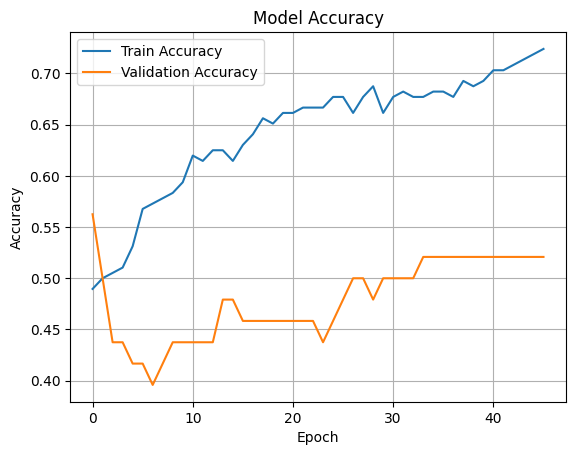

In [26]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()

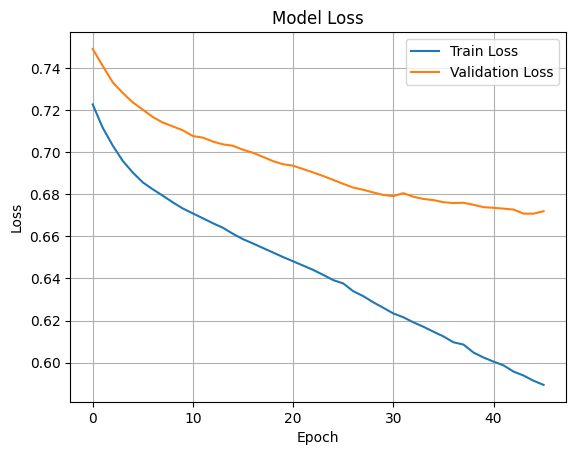

In [27]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)
plt.show()